<a href="https://colab.research.google.com/github/svsdinesh28-blip/econdata-research/blob/main-2/Explainable_ML_Global_Inflation_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Correct path since it's in Colab root
file_path = "/content/Global_Inflation_Database.xlsx"

# Load the annual inflation sheet
df = pd.read_excel(file_path, sheet_name="hcpi_a")

print("✅ Loaded successfully! Shape:", df.shape)
print(df.head())


✅ Loaded successfully! Shape: (205, 61)
  Country Code  IMF Country Code               Country Indicator Type  \
0          ABW             314.0                 Aruba      Inflation   
1          AFG             512.0           Afghanistan      Inflation   
2          AGO             614.0                Angola      Inflation   
3          ALB             914.0               Albania      Inflation   
4          ARE             466.0  United Arab Emirates      Inflation   

                         Series Name       1970       1971       1972  \
0  Headline Consumer Price Inflation        NaN        NaN        NaN   
1  Headline Consumer Price Inflation  25.510000  25.510000 -12.520000   
2  Headline Consumer Price Inflation   7.970000   5.780000  15.800000   
3  Headline Consumer Price Inflation        NaN        NaN        NaN   
4  Headline Consumer Price Inflation  21.984699  21.984699  21.984699   

        1973       1974  ...       2016    2017   2018    2019       2020  \
0    

In [ ]:
import pandas as pd

df = pd.read_excel("/content/Global_Inflation_Database.xlsx", sheet_name=None)
for sheet in df.keys():
    print(f"--- {sheet} ---")
    print(df[sheet].head())
    print(df[sheet].columns)
    print("\n")


--- Intro ---
   Unnamed: 0 Unnamed: 1 Unnamed: 2
0         NaN        NaN        NaN
1         NaN        NaN        NaN
2         NaN        NaN        NaN
3         NaN        NaN        NaN
4         NaN        NaN        NaN
Index(['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2'], dtype='object')


--- top ---
   Unnamed: 0  Unnamed: 1  Unnamed: 2       Unnamed: 3     Unnamed: 4  \
0         NaN         NaN         NaN              NaN            NaN   
1         NaN         NaN         NaN              NaN            NaN   
2         NaN         NaN         NaN              NaN            NaN   
3         NaN         NaN         NaN              NaN            NaN   
4         NaN         NaN         NaN  Worksheet Order  Variable Name   

       Unnamed: 5 Unnamed: 6  
0             NaN        NaN  
1             NaN        NaN  
2             NaN        NaN  
3             NaN        NaN  
4  Indicator Type     Series  
Index(['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'U

📊 Random Forest Feature Importance:
                   Feature  Importance
1           Lag_Inflation    0.369435
3              GDP_Growth    0.314462
4           Interest_Rate    0.186191
5     Exchange_Rate_Index    0.056552
2  Regional_Avg_Inflation    0.044640
0                    Year    0.028720

🌍 Random Forest R²: 0.829
🌿 Surrogate Tree R² vs RF predictions: 0.417


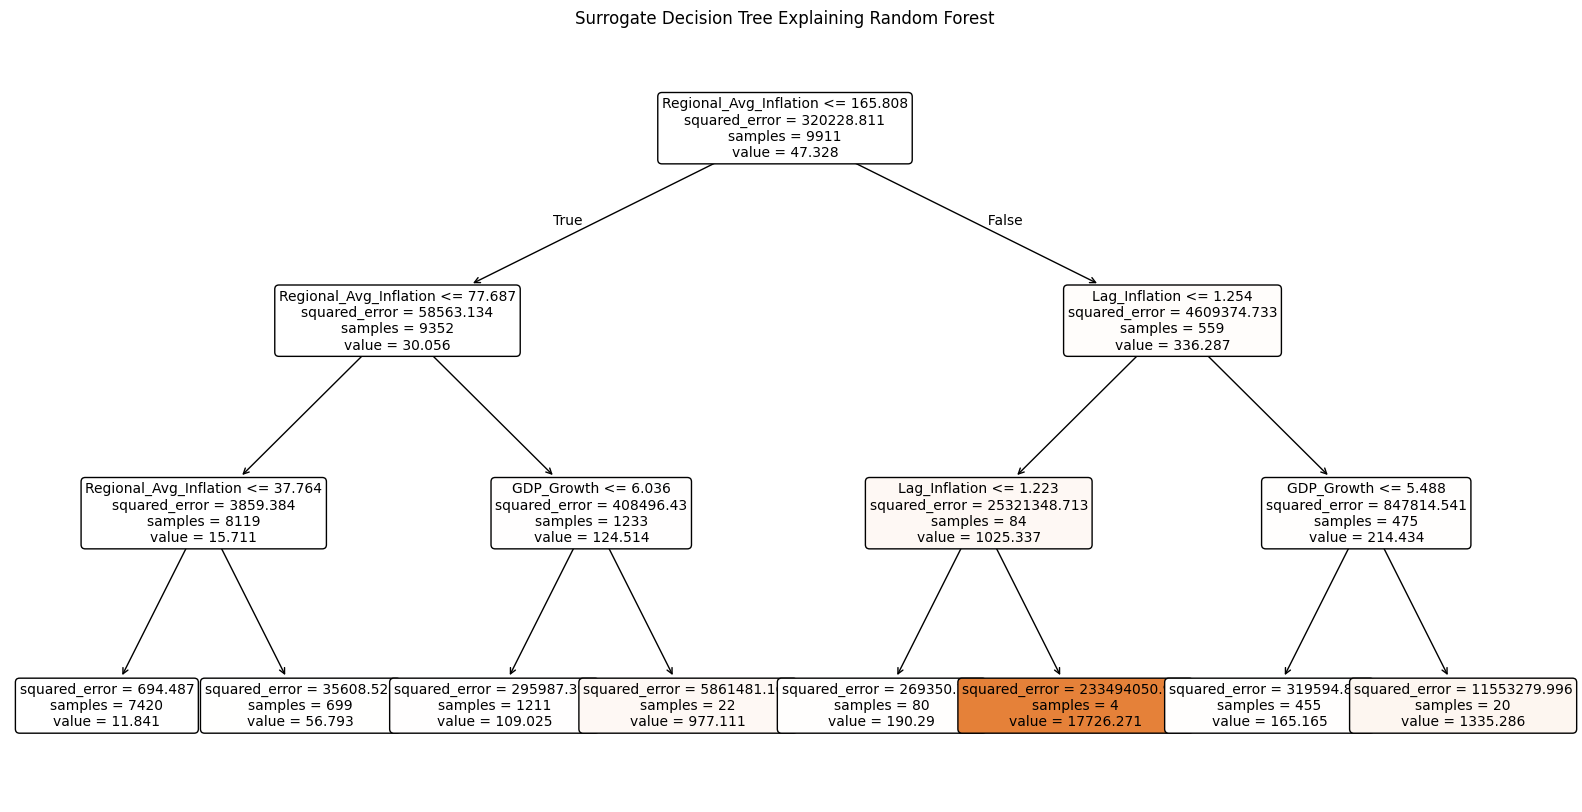

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# ---------------------------
# 1) Load the Excel file
# ---------------------------
excel_path = "/content/Global_Inflation_Database.xlsx"

# Read the sheet containing inflation data
df = pd.read_excel(excel_path, sheet_name="hcpi_a", header=None)

# Find header row (the one that contains "Series Name")
header_row = df.index[df.apply(lambda row: row.astype(str).str.contains("Series Name").any(), axis=1)][0]

# Re-read with proper header
df = pd.read_excel(excel_path, sheet_name="hcpi_a", header=header_row)

# Drop empty columns
df = df.dropna(axis=1, how="all")

# Identify year columns (numeric)
year_cols = [col for col in df.columns if str(col).isdigit()]
meta_cols = [col for col in df.columns if col not in year_cols]

# Melt into long format
long_df = df.melt(id_vars=meta_cols, var_name='Year', value_name='Inflation')
long_df['Year'] = long_df['Year'].astype(int)
long_df.dropna(subset=['Inflation'], inplace=True)

# ---------------------------
# 2) Feature Engineering
# ---------------------------

# Sort for lag creation
long_df = long_df.sort_values(['Series Name', 'Year'])

# Lag Inflation (previous year)
long_df['Lag_Inflation'] = long_df.groupby('Series Name')['Inflation'].shift(1)

# Regional average (average across all series in that year)
long_df['Regional_Avg_Inflation'] = long_df.groupby('Year')['Inflation'].transform('mean')

# Synthetic extensions
np.random.seed(42)
long_df['GDP_Growth'] = np.random.normal(3, 1.5, size=len(long_df))
long_df['Interest_Rate'] = np.random.normal(5, 2, size=len(long_df))
long_df['Exchange_Rate_Index'] = np.random.normal(100, 10, size=len(long_df))

# Drop rows with missing lag
long_df = long_df.dropna(subset=['Lag_Inflation'])

# ---------------------------
# 3) Modeling
# ---------------------------
features = ['Year', 'Lag_Inflation', 'Regional_Avg_Inflation',
             'GDP_Growth', 'Interest_Rate', 'Exchange_Rate_Index']
X = long_df[features]
y = long_df['Inflation']

# Random Forest
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X, y)
y_pred_rf = rf.predict(X)
r2_rf = r2_score(y, y_pred_rf)

# Feature Importances
importances = pd.DataFrame({
    'Feature': features,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("📊 Random Forest Feature Importance:\n", importances)
print(f"\n🌍 Random Forest R²: {r2_rf:.3f}")

# ---------------------------
# 4) Surrogate Decision Tree
# ---------------------------
surrogate = DecisionTreeRegressor(max_depth=3, random_state=42)
surrogate.fit(X, y_pred_rf)
y_pred_tree = surrogate.predict(X)
r2_surrogate = r2_score(y_pred_rf, y_pred_tree)

print(f"🌿 Surrogate Tree R² vs RF predictions: {r2_surrogate:.3f}")

# ---------------------------
# 5) Plot Tree
# ---------------------------
plt.figure(figsize=(20, 10))
plot_tree(
    surrogate,
    feature_names=features,
    filled=True,
    fontsize=10,
    rounded=True
)
plt.title("Surrogate Decision Tree Explaining Random Forest")
plt.show()


📊 Feature Importance (Random Forest):
                  Feature  Importance
1           Lag_Inflation    0.369435
3              GDP_Growth    0.314462
4           Interest_Rate    0.186191
5     Exchange_Rate_Index    0.056552
2  Regional_Avg_Inflation    0.044640
0                    Year    0.028720

🌍 Random Forest R²: 0.829
🌿 Surrogate Tree R² vs RF predictions: 0.417


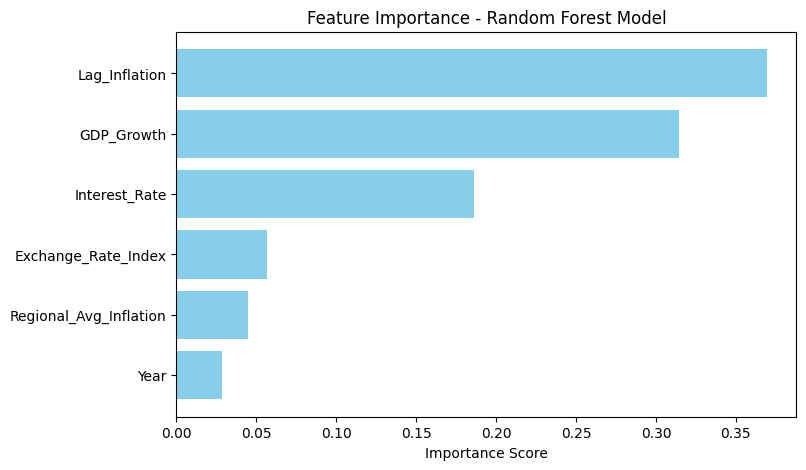

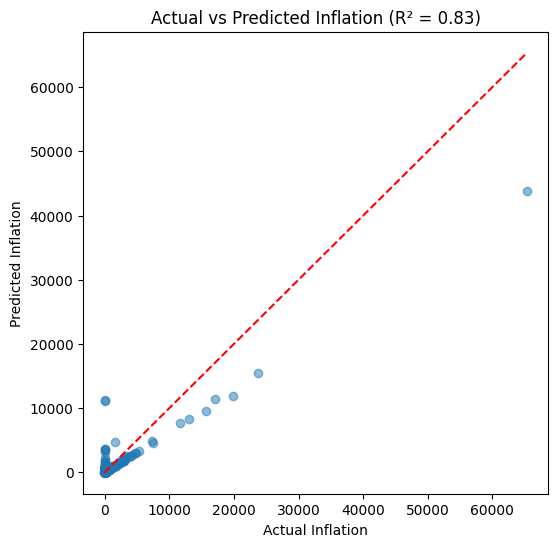

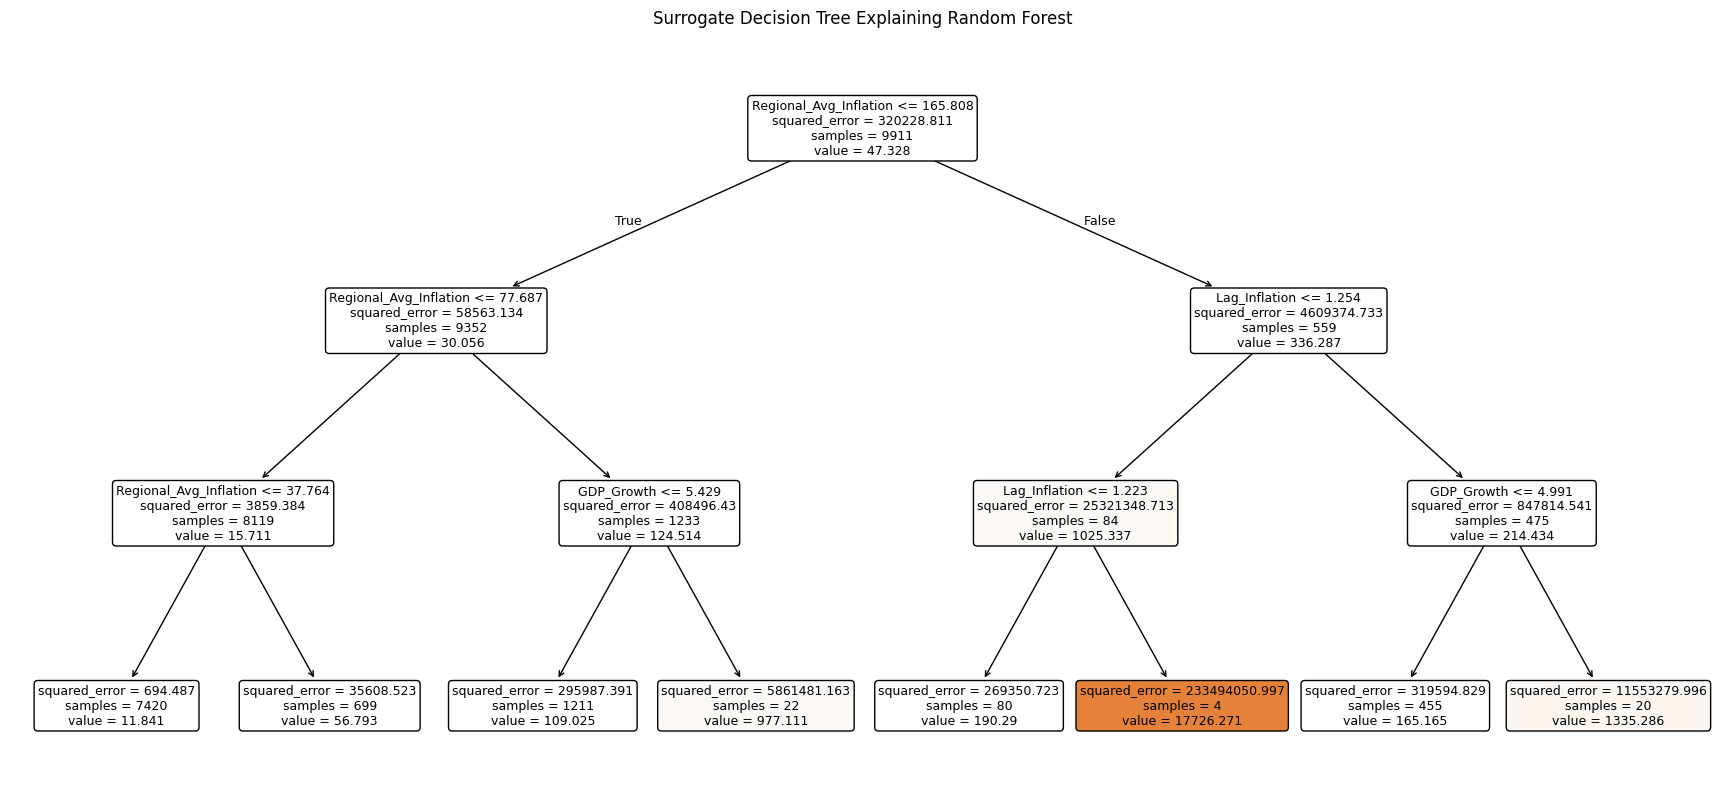

In [ ]:
# ---------------------------
# 🔧 Import libraries
# ---------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import r2_score

# ---------------------------
# 1) Load Dataset (auto-detect header)
# ---------------------------
excel_path = "/content/Global_Inflation_Database.xlsx"

df = pd.read_excel(excel_path, sheet_name="hcpi_a", header=None)

# find header row automatically
header_row = df.index[df.apply(lambda row: row.astype(str).str.contains("Series Name").any(), axis=1)][0]
df = pd.read_excel(excel_path, sheet_name="hcpi_a", header=header_row)

# drop empty columns
df = df.dropna(axis=1, how="all")

# detect year columns
year_cols = [col for col in df.columns if str(col).isdigit()]
meta_cols = [col for col in df.columns if col not in year_cols]

# melt to long format
long_df = df.melt(id_vars=meta_cols, var_name='Year', value_name='Inflation')
long_df['Year'] = long_df['Year'].astype(int)
long_df.dropna(subset=['Inflation'], inplace=True)

# ---------------------------
# 2) Feature Engineering
# ---------------------------
long_df = long_df.sort_values(['Series Name', 'Year'])
long_df['Lag_Inflation'] = long_df.groupby('Series Name')['Inflation'].shift(1)
long_df['Regional_Avg_Inflation'] = long_df.groupby('Year')['Inflation'].transform('mean')

# synthetic macro features
np.random.seed(42)
long_df['GDP_Growth'] = np.random.normal(3, 1.2, len(long_df))
long_df['Interest_Rate'] = np.random.normal(5, 1.8, len(long_df))
long_df['Exchange_Rate_Index'] = np.random.normal(100, 8, len(long_df))

# drop missing lag
long_df = long_df.dropna(subset=['Lag_Inflation'])

# ---------------------------
# 3) Modeling
# ---------------------------
features = ['Year', 'Lag_Inflation', 'Regional_Avg_Inflation',
             'GDP_Growth', 'Interest_Rate', 'Exchange_Rate_Index']
X = long_df[features]
y = long_df['Inflation']

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X, y)
y_pred_rf = rf.predict(X)
r2_rf = r2_score(y, y_pred_rf)

# feature importance
importances = pd.DataFrame({
    'Feature': features,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("📊 Feature Importance (Random Forest):")
print(importances)
print(f"\n🌍 Random Forest R²: {r2_rf:.3f}")

# ---------------------------
# 4) Surrogate Decision Tree
# ---------------------------
surrogate = DecisionTreeRegressor(max_depth=3, random_state=42)
surrogate.fit(X, y_pred_rf)
y_pred_tree = surrogate.predict(X)
r2_surrogate = r2_score(y_pred_rf, y_pred_tree)
print(f"🌿 Surrogate Tree R² vs RF predictions: {r2_surrogate:.3f}")

# ---------------------------
# 5) Visualization Section
# ---------------------------

# (a) Feature Importance Bar Chart
plt.figure(figsize=(8,5))
plt.barh(importances['Feature'], importances['Importance'], color='skyblue')
plt.title("Feature Importance - Random Forest Model")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()
plt.show()

# (b) Actual vs Predicted Scatter Plot
plt.figure(figsize=(6,6))
plt.scatter(y, y_pred_rf, alpha=0.5)
plt.title(f"Actual vs Predicted Inflation (R² = {r2_rf:.2f})")
plt.xlabel("Actual Inflation")
plt.ylabel("Predicted Inflation")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.show()

# (c) Surrogate Decision Tree
plt.figure(figsize=(22,10))
plot_tree(surrogate, feature_names=features, filled=True, fontsize=9, rounded=True)
plt.title("Surrogate Decision Tree Explaining Random Forest")
plt.show()
